# 📝 Exercise M7.01

In this exercise we will define dummy classification baselines and use them as
reference to assess the relative predictive performance of a given model of
interest.

We illustrate those baselines with the help of the Adult Census dataset, using
only the numerical features for the sake of simplicity.

In [74]:
import pandas as pd

adult_census = pd.read_csv("../datasets/adult-census-numeric-all.csv")
data, target = adult_census.drop(columns="class"), adult_census["class"]

First, define a `ShuffleSplit` cross-validation strategy taking half of the
samples as a testing at each round. Let us use 10 cross-validation rounds.

In [75]:
# Write your code here.
from sklearn.model_selection import ShuffleSplit

shuffle_split = ShuffleSplit(test_size=0.5, n_splits=10, random_state=0)

Next, create a machine learning pipeline composed of a transformer to
standardize the data followed by a logistic regression classifier.

In [76]:
# Write your code here.
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

Compute the cross-validation (test) scores for the classifier on this dataset.
Store the results pandas Series as we did in the previous notebook.

In [77]:
# Write your code here.
from sklearn.model_selection import cross_validate

cv_results = cross_validate(model, data, target, return_train_score=True, cv=shuffle_split, n_jobs=2)
cv_results = pd.Series(cv_results["test_score"], name="logistic regression cv test scores")
cv_results

0    0.815937
1    0.813849
2    0.815036
3    0.815569
4    0.810982
5    0.814831
6    0.813112
7    0.810368
8    0.812375
9    0.816306
Name: logistic regression cv test scores, dtype: float64

Now, compute the cross-validation scores of a dummy classifier that constantly
predicts the most frequent class observed the training set. Please refer to
the online documentation for the [sklearn.dummy.DummyClassifier
](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
class.

Store the results in a second pandas Series.

In [78]:
# Write your code here.
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy="most_frequent")
cv_results_dummy = cross_validate(model_dummy, data, target, return_train_score=True, cv=shuffle_split, n_jobs=2)
cv_results_dummy = pd.Series(cv_results_dummy["test_score"], name="dummy cv test scores")

Now that we collected the results from the baseline and the model, concatenate
the test scores as columns a single pandas dataframe.

In [79]:
# Write your code here.
all_errors = pd.concat(
    [cv_results_dummy, cv_results],
    axis=1,
)
all_errors

,dummy cv test scores,logistic regression cv test scores
0,0.760329,0.815937
1,0.756808,0.813849
2,0.759142,0.815036
3,0.760739,0.815569
4,0.761681,0.810982
5,0.761885,0.814831
6,0.757463,0.813112
7,0.757176,0.810368
8,0.761885,0.812375
9,0.763114,0.816306



Next, plot the histogram of the cross-validation test scores for both models
with the help of [pandas built-in plotting
function](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#histograms).

What conclusions do you draw from the results?

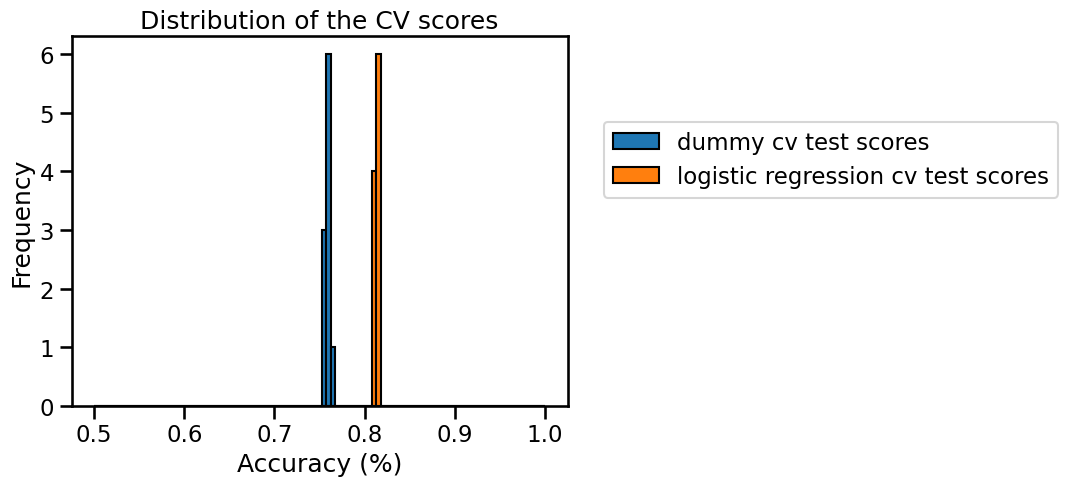

In [80]:
# Write your code here.
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(start=0.5, stop=1.0, num=100)
all_errors.plot.hist(bins=bins, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Accuracy (%)")
_ = plt.title("Distribution of the CV scores")

Change the `strategy` of the dummy classifier to `"stratified"`, compute the
results. Similarly compute scores for `strategy="uniform"` and then the  plot
the distribution together with the other results.

Are those new baselines better than the previous one? Why is this the case?

Please refer to the scikit-learn documentation on
[sklearn.dummy.DummyClassifier](
https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
to find out about the meaning of the `"stratified"` and `"uniform"`
strategies.

In [81]:
# Write your code here.
stratified_dummy = DummyClassifier(strategy="stratified")
cv_results_stratified = cross_validate(
    stratified_dummy, data, target, cv=shuffle_split, n_jobs=2
)
test_score_dummy_stratified = pd.Series(
    cv_results_stratified["test_score"], name="Stratified class predictor"
)

In [82]:
uniform_dummy = DummyClassifier(strategy="uniform")
cv_results_uniform = cross_validate(
    uniform_dummy, data, target, cv=shuffle_split, n_jobs=2
)
test_score_dummy_uniform = pd.Series(
    cv_results_uniform["test_score"], name="Uniform class predictor"
)

In [83]:
all_test_scores = pd.concat(
    [
        cv_results,
        cv_results_dummy,
        test_score_dummy_stratified,
        test_score_dummy_uniform,
    ],
    axis="columns",
)

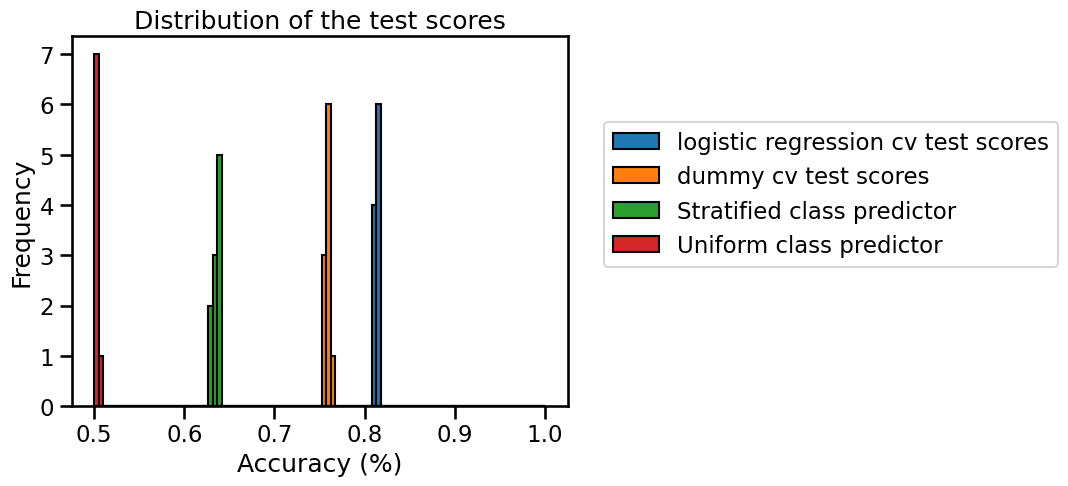

In [ ]:
all_test_scores.plot.hist(bins=bins, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Accuracy (%)")
_ = plt.title("Distribution of the test scores")